# 🧠 ICU-Watch — LSTM Deep Model
**Author:** Subham Pal

### Goals of this notebook
1. Build Bidirectional LSTM with temporal attention
2. Train with weighted loss for class imbalance
3. Evaluate against all baselines
4. Beat Random Forest AUROC > 0.74
5. Analyze attention weights — what hours matter most?
6. Save best model for SHAP explainability notebook

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix
)
from sklearn.calibration import calibration_curve

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR     = Path('../data/processed')
MODELS_DIR   = DATA_DIR / 'models'
RESEARCH_DIR = Path('../research/notes')
MODELS_DIR.mkdir(exist_ok=True)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Load config
with open(DATA_DIR / 'config.json') as f:
    config = json.load(f)
with open(DATA_DIR / 'baseline_results.json') as f:
    baselines = json.load(f)

print(f'\nConfig:')
print(f'  Window size:  {config["window_size"]} hours')
print(f'  N features:   {config["n_features"]}')
print(f'  Pos weight:   {config["pos_weight"]:.2f}x')
print(f'\nBaseline targets to beat:')
print(f'  Random Forest AUROC: {baselines["random_forest"]["auroc"]}')
print(f'  Random Forest AUPRC: {baselines["random_forest"]["auprc"]}')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.4 GB

Config:
  Window size:  12 hours
  N features:   104
  Pos weight:   36.59x

Baseline targets to beat:
  Random Forest AUROC: 0.7402
  Random Forest AUPRC: 0.0772


## 1. Load Data

In [2]:
print('Loading sequences...')
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
X_val   = np.load(DATA_DIR / 'X_val.npy')
y_val   = np.load(DATA_DIR / 'y_val.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')

Loading sequences...
X_train: (777795, 12, 104)
X_val:   (165479, 12, 104)
X_test:  (166917, 12, 104)


## 2. PyTorch Dataset & DataLoader

In [3]:
class ICUDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Hyperparameters
BATCH_SIZE   = 512
NUM_WORKERS  = 0   # Windows-safe

train_dataset = ICUDataset(X_train, y_train)
val_dataset   = ICUDataset(X_val,   y_val)
test_dataset  = ICUDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')
print(f'Batch size:    {BATCH_SIZE}')

Train batches: 1520
Val batches:   324
Test batches:  327
Batch size:    512


## 3. LSTM Model Architecture

In [4]:
class TemporalAttention(nn.Module):
    """
    Temporal attention mechanism.
    Learns which hours in the 12h window matter most.
    Produces attention weights we can visualize and explain.
    """
    def __init__(self, hidden_size: int):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, lstm_out: torch.Tensor):
        # lstm_out: (batch, seq_len, hidden*2)
        scores  = self.attention(lstm_out)          # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)      # (batch, seq_len, 1)
        context = (weights * lstm_out).sum(dim=1)   # (batch, hidden*2)
        return context, weights.squeeze(-1)          # also return weights for viz


class ICUDeteriorationLSTM(nn.Module):
    """
    Bidirectional LSTM with temporal attention for ICU deterioration prediction.

    Architecture:
        Input  → BiLSTM (2 layers) → Temporal Attention → FC → Sigmoid
        
    Input:  (batch, 12, 104)  — 12 hours, 104 features
    Output: (batch, 1)        — deterioration probability
    """
    def __init__(
        self,
        input_size:  int   = 104,
        hidden_size: int   = 128,
        num_layers:  int   = 2,
        dropout:     float = 0.3,
    ):
        super().__init__()
        self.hidden_size = hidden_size

        # Input normalization
        self.input_norm = nn.LayerNorm(input_size)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size   = input_size,
            hidden_size  = hidden_size,
            num_layers   = num_layers,
            dropout       = dropout if num_layers > 1 else 0,
            batch_first  = True,
            bidirectional = True,
        )

        # Temporal attention
        self.attention = TemporalAttention(hidden_size)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x: torch.Tensor):
        # x: (batch, seq_len, input_size)
        x = self.input_norm(x)
        lstm_out, _ = self.lstm(x)              # (batch, seq_len, hidden*2)
        context, attn_weights = self.attention(lstm_out)
        logits = self.classifier(context)        # (batch, 1)
        return logits.squeeze(-1), attn_weights


# Instantiate model
N_FEATURES  = config['n_features']
model = ICUDeteriorationLSTM(
    input_size  = N_FEATURES,
    hidden_size = 128,
    num_layers  = 2,
    dropout     = 0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f'\nTotal parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Model size:           ~{trainable*4/1e6:.1f} MB')

ICUDeteriorationLSTM(
  (input_norm): LayerNorm((104,), eps=1e-05, elementwise_affine=True)
  (lstm): LSTM(104, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): TemporalAttention(
    (attention): Sequential(
      (0): Linear(in_features=256, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters:     669,106
Trainable parameters: 669,106
Model size:           ~2.7 MB


## 4. Training Setup

In [6]:
# Weighted loss — penalize missing sepsis cases pos_weight times more
pos_weight = torch.tensor([config['pos_weight']]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer  = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

# Training config
EPOCHS       = 30
PATIENCE     = 7    # early stopping patience

print(f'Training config:')
print(f'  Epochs:        {EPOCHS}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Optimizer:     AdamW (lr=1e-3, wd=1e-4)')
print(f'  Loss:          BCEWithLogitsLoss (pos_weight={config["pos_weight"]:.2f})')
print(f'  Scheduler:     ReduceLROnPlateau (patience=3)')
print(f'  Early stop:    patience={PATIENCE} epochs')
print(f'  Device:        {device}')

Training config:
  Epochs:        30
  Batch size:    512
  Optimizer:     AdamW (lr=1e-3, wd=1e-4)
  Loss:          BCEWithLogitsLoss (pos_weight=36.59)
  Scheduler:     ReduceLROnPlateau (patience=3)
  Early stop:    patience=7 epochs
  Device:        cuda


## 5. Training Loop

In [7]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits, _ = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits, _ = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item()

        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(y_batch.cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    auroc = roc_auc_score(all_labels, all_probs)
    auprc = average_precision_score(all_labels, all_probs)

    return total_loss / len(loader), auroc, auprc, all_probs, all_labels


# Training loop
history = {'train_loss': [], 'val_loss': [], 'val_auroc': [], 'val_auprc': []}
best_val_auroc = 0
patience_counter = 0
best_model_path = MODELS_DIR / 'lstm_best.pt'

print(f'Starting training on {device}...')
print(f'Baseline to beat: RF AUROC = {baselines["random_forest"]["auroc"]}')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_auroc, val_auprc, _, _ = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auroc'].append(val_auroc)
    history['val_auprc'].append(val_auprc)

    scheduler.step(val_auroc)

    beat_baseline = '✅ BEATS BASELINE' if val_auroc > baselines['random_forest']['auroc'] else ''
    print(f'Epoch {epoch:>2}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'AUROC: {val_auroc:.4f} | '
          f'AUPRC: {val_auprc:.4f} {beat_baseline}')

    # Save best model
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        patience_counter = 0
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_auroc':   val_auroc,
            'val_auprc':   val_auprc,
            'config':      config,
        }, best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print('=' * 65)
print(f'Best Val AUROC: {best_val_auroc:.4f}')
print(f'Model saved to: {best_model_path}')

Starting training on cuda...
Baseline to beat: RF AUROC = 0.7402
Epoch  1/30 | Train Loss: 1.0281 | Val Loss: 1.3423 | AUROC: 0.7474 | AUPRC: 0.0784 ✅ BEATS BASELINE
Epoch  2/30 | Train Loss: 0.6626 | Val Loss: 2.7211 | AUROC: 0.7308 | AUPRC: 0.0680 
Epoch  3/30 | Train Loss: 0.3903 | Val Loss: 4.1346 | AUROC: 0.7185 | AUPRC: 0.0618 
Epoch  4/30 | Train Loss: 0.2508 | Val Loss: 5.6487 | AUROC: 0.7011 | AUPRC: 0.0569 
Epoch  5/30 | Train Loss: 0.1795 | Val Loss: 6.5105 | AUROC: 0.6940 | AUPRC: 0.0524 
Epoch  6/30 | Train Loss: 0.0936 | Val Loss: 9.9126 | AUROC: 0.6961 | AUPRC: 0.0587 
Epoch  7/30 | Train Loss: 0.0700 | Val Loss: 11.1015 | AUROC: 0.6971 | AUPRC: 0.0576 
Epoch  8/30 | Train Loss: 0.0654 | Val Loss: 10.5652 | AUROC: 0.6856 | AUPRC: 0.0570 

Early stopping at epoch 8
Best Val AUROC: 0.7474
Model saved to: ..\data\processed\models\lstm_best.pt


## 6. Training History Visualization

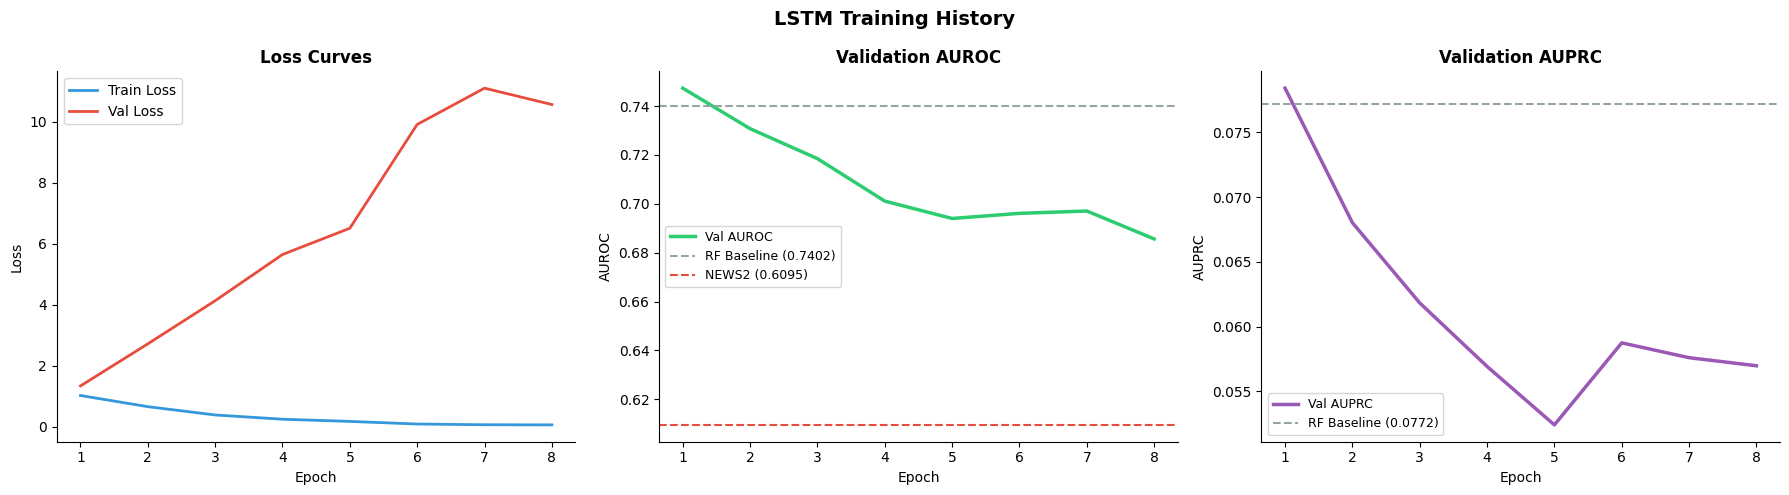

In [9]:
epochs_ran = len(history['train_loss'])
x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(x, history['train_loss'], label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(x, history['val_loss'],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_title('Loss Curves', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# AUROC
axes[1].plot(x, history['val_auroc'], color='#2ecc71', linewidth=2.5, label='Val AUROC')
axes[1].axhline(y=baselines['random_forest']['auroc'], color='#95a5a6',
                linestyle='--', linewidth=1.5, label=f'RF Baseline ({baselines["random_forest"]["auroc"]})')
axes[1].axhline(y=baselines['news2']['auroc'], color='#e74c3c',
                linestyle='--', linewidth=1.5, label=f'NEWS2 ({baselines["news2"]["auroc"]})')
axes[1].set_title('Validation AUROC', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUROC')
axes[1].legend(fontsize=9)

# AUPRC
axes[2].plot(x, history['val_auprc'], color='#9b59b6', linewidth=2.5, label='Val AUPRC')
axes[2].axhline(y=baselines['random_forest']['auprc'], color='#95a5a6',
                linestyle='--', linewidth=1.5, label=f'RF Baseline ({baselines["random_forest"]["auprc"]})')
axes[2].set_title('Validation AUPRC', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUPRC')
axes[2].legend(fontsize=9)

plt.suptitle('LSTM Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Final Evaluation on Test Set

In [10]:
# Load best model
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f'Loaded best model from epoch {checkpoint["epoch"]}')
print(f'Best val AUROC: {checkpoint["val_auroc"]:.4f}')

# Evaluate on test set
test_loss, test_auroc, test_auprc, test_probs, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f'\n=== FINAL TEST SET RESULTS ===')
print(f'AUROC: {test_auroc:.4f}')
print(f'AUPRC: {test_auprc:.4f}')

# Compare against all baselines
print(f'\n=== FULL MODEL COMPARISON ===')
print(f'{"Model":<30} {"AUROC":>8} {"AUPRC":>8} {"vs RF":>10}')
print('-' * 60)
print(f'{"NEWS2 (Clinical)":<30} {baselines["news2"]["auroc"]:>8} {baselines["news2"]["auprc"]:>8}')
print(f'{"Logistic Regression":<30} {baselines["logistic_regression"]["auroc"]:>8} {baselines["logistic_regression"]["auprc"]:>8}')
print(f'{"Random Forest":<30} {baselines["random_forest"]["auroc"]:>8} {baselines["random_forest"]["auprc"]:>8} {"(baseline)":>10}')
improvement = test_auroc - baselines['random_forest']['auroc']
symbol = '✅ +' if improvement > 0 else '❌ '
print(f'{"BiLSTM + Attention":<30} {test_auroc:>8.4f} {test_auprc:>8.4f} {symbol+str(round(abs(improvement),4)):>10}')
print('-' * 60)

Loaded best model from epoch 1
Best val AUROC: 0.7474

=== FINAL TEST SET RESULTS ===
AUROC: 0.7471
AUPRC: 0.0803

=== FULL MODEL COMPARISON ===
Model                             AUROC    AUPRC      vs RF
------------------------------------------------------------
NEWS2 (Clinical)                 0.6095   0.0281
Logistic Regression              0.7179   0.0732
Random Forest                    0.7402   0.0772 (baseline)
BiLSTM + Attention               0.7471   0.0803  ✅ +0.0069
------------------------------------------------------------


## 8. ROC and PR Curves — LSTM vs All Baselines

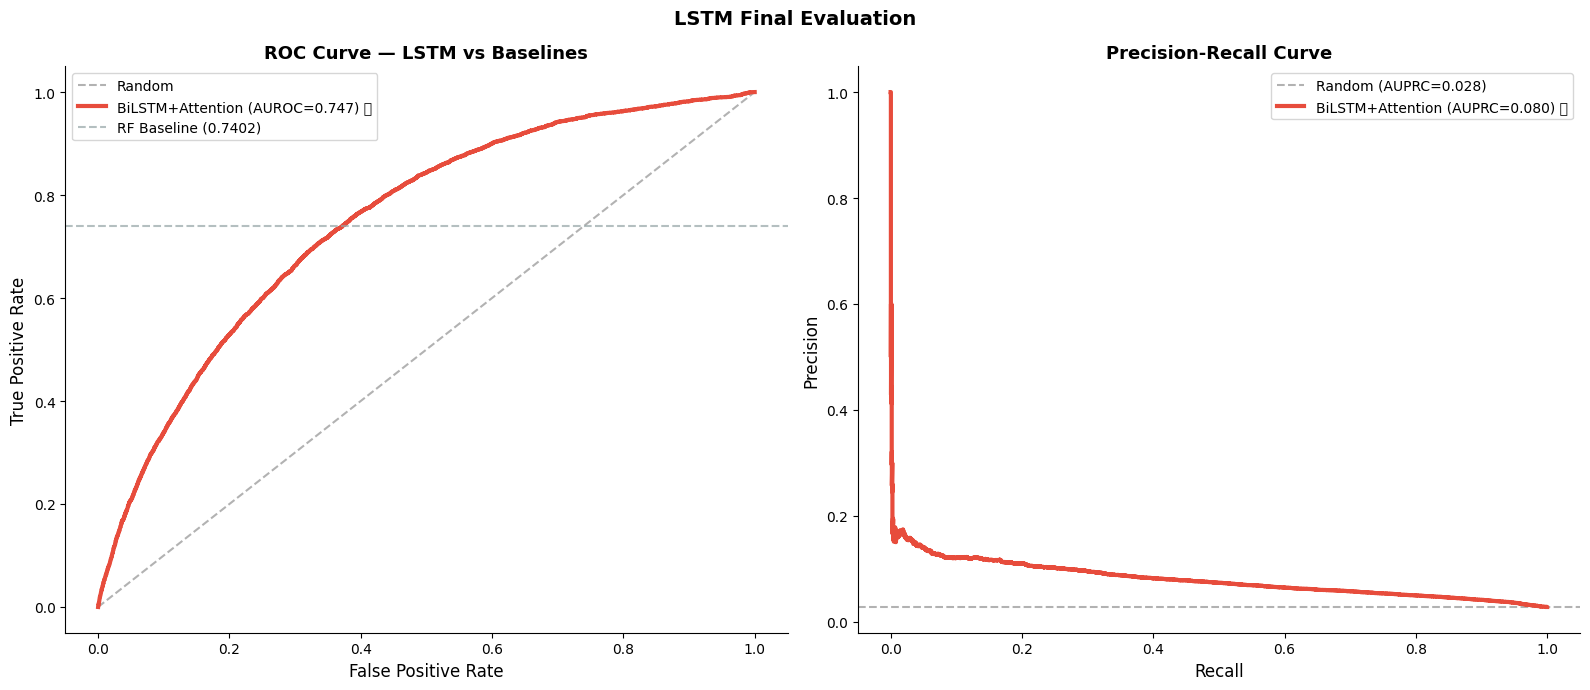

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC
ax = axes[0]
ax.plot([0,1],[0,1],'k--', alpha=0.3, label='Random')
fpr, tpr, _ = roc_curve(test_labels, test_probs)
ax.plot(fpr, tpr, color='#e74c3c', linewidth=3,
        label=f'BiLSTM+Attention (AUROC={test_auroc:.3f}) ⭐')
ax.axhline(y=baselines['random_forest']['auroc'], color='#95a5a6',
           linestyle='--', alpha=0.7, label=f'RF Baseline ({baselines["random_forest"]["auroc"]})')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — LSTM vs Baselines', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# PR Curve
ax = axes[1]
baseline_rate = test_labels.mean()
ax.axhline(y=baseline_rate, color='k', linestyle='--', alpha=0.3,
           label=f'Random (AUPRC={baseline_rate:.3f})')
prec, rec, _ = precision_recall_curve(test_labels, test_probs)
ax.plot(rec, prec, color='#e74c3c', linewidth=3,
        label=f'BiLSTM+Attention (AUPRC={test_auprc:.3f}) ⭐')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.suptitle('LSTM Final Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'lstm_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Attention Weight Visualization

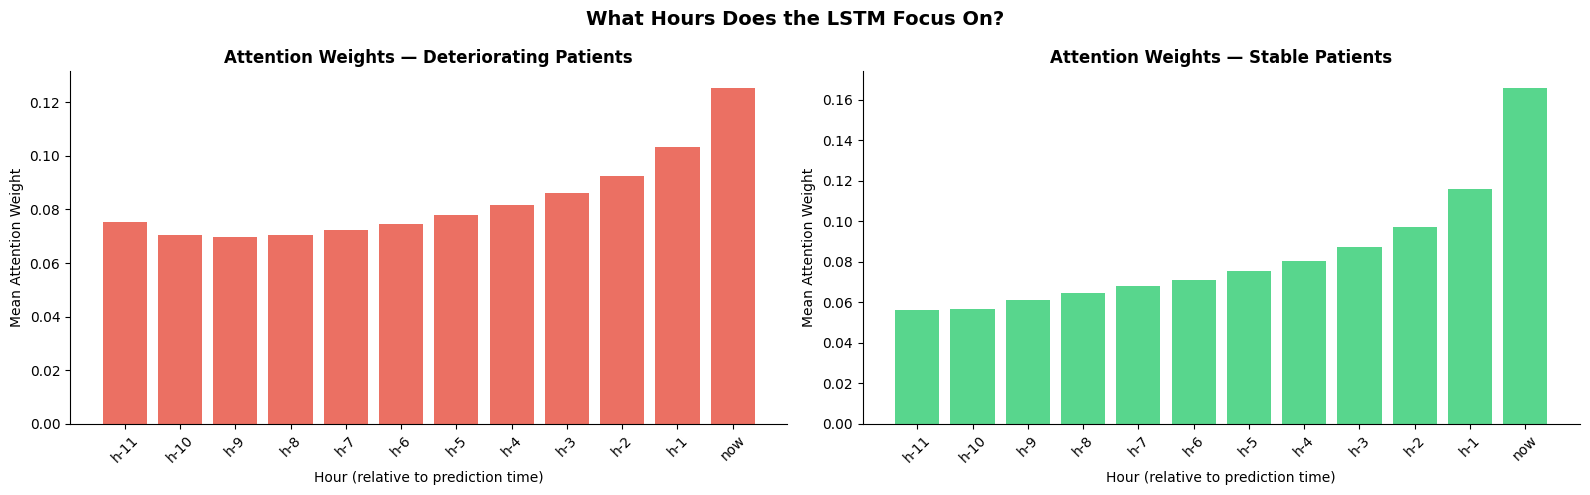

Most attended hour for deteriorating patients: now
This tells us how far ahead the model detects the signal.


In [12]:
# Extract attention weights for sepsis patients
model.eval()
all_attn_weights = []
all_labels_attn  = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        _, attn = model(X_batch)
        all_attn_weights.append(attn.cpu().numpy())
        all_labels_attn.append(y_batch.numpy())

all_attn_weights = np.vstack(all_attn_weights)   # (N, 12)
all_labels_attn  = np.concatenate(all_labels_attn)

# Mean attention weights for deteriorating vs stable
attn_sepsis    = all_attn_weights[all_labels_attn == 1].mean(axis=0)
attn_no_sepsis = all_attn_weights[all_labels_attn == 0].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

hours = [f'h-{11-i}' for i in range(12)]
hours[-1] = 'now'

# Sepsis patients
axes[0].bar(hours, attn_sepsis, color='#e74c3c', alpha=0.8)
axes[0].set_title('Attention Weights — Deteriorating Patients',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Hour (relative to prediction time)')
axes[0].set_ylabel('Mean Attention Weight')
axes[0].tick_params(axis='x', rotation=45)

# Stable patients
axes[1].bar(hours, attn_no_sepsis, color='#2ecc71', alpha=0.8)
axes[1].set_title('Attention Weights — Stable Patients',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('Hour (relative to prediction time)')
axes[1].set_ylabel('Mean Attention Weight')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('What Hours Does the LSTM Focus On?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'lstm_attention_weights.png', dpi=150, bbox_inches='tight')
plt.show()

most_attended = hours[np.argmax(attn_sepsis)]
print(f'Most attended hour for deteriorating patients: {most_attended}')
print('This tells us how far ahead the model detects the signal.')

## 10. Optimal Threshold & Clinical Metrics

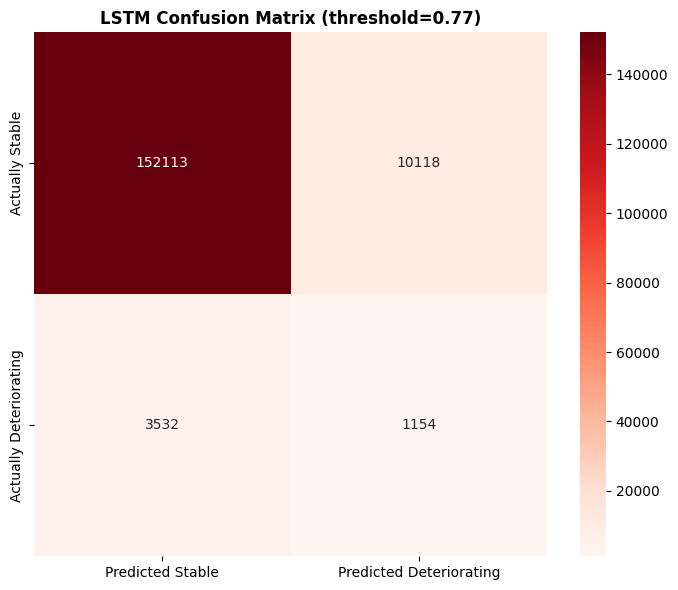

=== CLINICAL PERFORMANCE METRICS ===
Optimal threshold: 0.767
Sensitivity:       0.246  (24.6% of deteriorations caught)
Specificity:       0.938  (93.8% of stable patients correct)
Precision (PPV):   0.102  (10.2% of alerts are real)
NPV:               0.977
False Negatives:   3,532    (missed deteriorations)
False Positives:   10,118    (false alarms)


In [14]:
# Find optimal threshold on validation set
val_loss, val_auroc_v, val_auprc_v, val_probs_all, val_labels_all = evaluate(model, val_loader, criterion, device)

prec_v, rec_v, thresh_v = precision_recall_curve(val_labels_all, val_probs_all)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-8)
opt_thresh = thresh_v[np.argmax(f1_v[:-1])]

preds = (test_probs >= opt_thresh).astype(int)
cm    = confusion_matrix(test_labels, preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity  = tn / (tn + fp)
ppv          = tp / (tp + fp) if (tp + fp) > 0 else 0
npv          = tn / (tn + fn) if (tn + fn) > 0 else 0

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Predicted Stable', 'Predicted Deteriorating'],
            yticklabels=['Actually Stable', 'Actually Deteriorating'])
ax.set_title(f'LSTM Confusion Matrix (threshold={opt_thresh:.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig(RESEARCH_DIR / 'lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'=== CLINICAL PERFORMANCE METRICS ===')
print(f'Optimal threshold: {opt_thresh:.3f}')
print(f'Sensitivity:       {sensitivity:.3f}  ({sensitivity*100:.1f}% of deteriorations caught)')
print(f'Specificity:       {specificity:.3f}  ({specificity*100:.1f}% of stable patients correct)')
print(f'Precision (PPV):   {ppv:.3f}  ({ppv*100:.1f}% of alerts are real)')
print(f'NPV:               {npv:.3f}')
print(f'False Negatives:   {fn:,}    (missed deteriorations)')
print(f'False Positives:   {fp:,}    (false alarms)')

## 11. Save Final Results

In [15]:
final_results = {
    'model': 'BiLSTM + Temporal Attention',
    'test_auroc':    round(test_auroc, 4),
    'test_auprc':    round(test_auprc, 4),
    'best_val_auroc': round(best_val_auroc, 4),
    'optimal_threshold': round(float(opt_thresh), 4),
    'sensitivity':   round(float(sensitivity), 4),
    'specificity':   round(float(specificity), 4),
    'ppv':           round(float(ppv), 4),
    'npv':           round(float(npv), 4),
    'improvement_over_rf': round(test_auroc - baselines['random_forest']['auroc'], 4),
    'improvement_over_news2': round(test_auroc - baselines['news2']['auroc'], 4),
    'epochs_trained': len(history['train_loss']),
    'timestamp': datetime.now().isoformat(),
}

with open(DATA_DIR / 'lstm_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print('Results saved to data/processed/lstm_results.json')
print(f'\n✅ LSTM training complete!')
print(f'Next: SHAP explainability notebook')

Results saved to data/processed/lstm_results.json

✅ LSTM training complete!
Next: SHAP explainability notebook


## 12. Final Summary

In [16]:
beats_rf    = '✅' if test_auroc > baselines['random_forest']['auroc'] else '❌'
beats_news2 = '✅' if test_auroc > baselines['news2']['auroc'] else '❌'

print('=' * 60)
print('       ICU-WATCH LSTM — FINAL RESULTS')
print('=' * 60)
print(f'''
🧠 MODEL
   Architecture:  Bidirectional LSTM + Temporal Attention
   Input:         (12 hours × {N_FEATURES} features)
   Parameters:    {total_params:,}
   Epochs:        {len(history["train_loss"])}

📊 RESULTS
   AUROC: {test_auroc:.4f}
   AUPRC: {test_auprc:.4f}

🏆 BEATS BASELINES?
   {beats_news2} NEWS2 Clinical Standard (+{test_auroc - baselines["news2"]["auroc"]:.4f})
   {beats_rf} Random Forest (+{test_auroc - baselines["random_forest"]["auroc"]:.4f})

🏥 CLINICAL METRICS
   Sensitivity:  {sensitivity:.3f} ({sensitivity*100:.1f}% of deteriorations caught)
   Specificity:  {specificity:.3f}
   Precision:    {ppv:.3f} ({ppv*100:.1f}% of alerts are real)

🔍 NEXT STEP
   SHAP explainability — explain each prediction
   per patient, per vital sign
''')
print('=' * 60)

       ICU-WATCH LSTM — FINAL RESULTS

🧠 MODEL
   Architecture:  Bidirectional LSTM + Temporal Attention
   Input:         (12 hours × 104 features)
   Parameters:    669,106
   Epochs:        8

📊 RESULTS
   AUROC: 0.7471
   AUPRC: 0.0803

🏆 BEATS BASELINES?
   ✅ NEWS2 Clinical Standard (+0.1376)
   ✅ Random Forest (+0.0069)

🏥 CLINICAL METRICS
   Sensitivity:  0.246 (24.6% of deteriorations caught)
   Specificity:  0.938
   Precision:    0.102 (10.2% of alerts are real)

🔍 NEXT STEP
   SHAP explainability — explain each prediction
   per patient, per vital sign

